<a href="https://colab.research.google.com/github/zeeshan3106/Deep-Learning/blob/main/Transfer%20Learning%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import tensorflow
from tensorflow.keras.applications import VGG16
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten

In [31]:
base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(150,150,3)

)

In [32]:
model = Sequential()
# model.add(Conv2D(64,(3,3), activation="relu", padding = "same",input_shape=(256,256,3)))
# model.add(Conv2D(64,(3,3), activation="relu", padding = "same"))
# model.add(Conv2D(64,(3,3), activation="relu", padding = "same"))
model.add(base)
model.add(Flatten())
model.add(Dense(10,activation = "relu"))
model.add(Dense(1,activation = "relu"))
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │        81,930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,796,629 (56.44 MB)

 Trainable params: 14,796,629 (56.44 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
base.trainable=False
model.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │        81,930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,796,629 (56.44 MB)

 Trainable params: 81,941 (320.08 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [44]:

import tensorflow_datasets as tfds


(train_ds, test_ds), info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

In [45]:
import tensorflow as tf

IMG_SIZE = 150
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 1495.0
    return image, label

train_ds = train_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [41]:
import tensorflow
from tensorflow.keras.applications import VGG16
base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(150,150,3)

)

base.trainable=False
set_trainable = False

for layer in base.layers:
  if layer.name=="block5_conv1":
    set_trainable=True
  if set_trainable:
    layer.trainable=True
  else:
      layer.trainable=False
for layer in base.layers:
  print(layer.name,layer.trainable)

input_layer_20 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [50]:
import tensorflow
from tensorflow.keras.applications import VGG16
base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(150,150,3)

)

base.trainable = False
set_trainable = False
for layer in base.layers:
  if layer.name=="block5_conv1":
    set_trainable=True
  if set_trainable:
    layer.trainable=True
  else:
    layer.trainable=False




from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten
model = Sequential()
# model.add(Conv2D(64,(3,3), activation="relu", padding = "same",input_shape=(256,256,3)))
# model.add(Conv2D(64,(3,3), activation="relu", padding = "same"))
# model.add(Conv2D(64,(3,3), activation="relu", padding = "same"))
model.add(base)
model.add(Flatten())
model.add(Dense(64,activation = "relu"))
model.add(Dense(32,activation = "relu"))
model.add(Dense(16,activation = "relu"))
model.add(Dense(1,activation = "sigmoid"))
model.summary()
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,241,665 (58.14 MB)

 Trainable params: 7,606,401 (29.02 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [52]:
history = model.fit(train_ds,epochs=2,validation_data=test_ds)

Epoch 1/2
582/582 ━━━━━━━━━━━━━━━━━━━━ 101s 173ms/step - accuracy: 0.8406 - loss: 0.3576 - val_accuracy: 0.8399 - val_loss: 0.3449
Epoch 2/2
582/582 ━━━━━━━━━━━━━━━━━━━━ 96s 165ms/step - accuracy: 0.8724 - loss: 0.2968 - val_accuracy: 0.8407 - val_loss: 0.3482


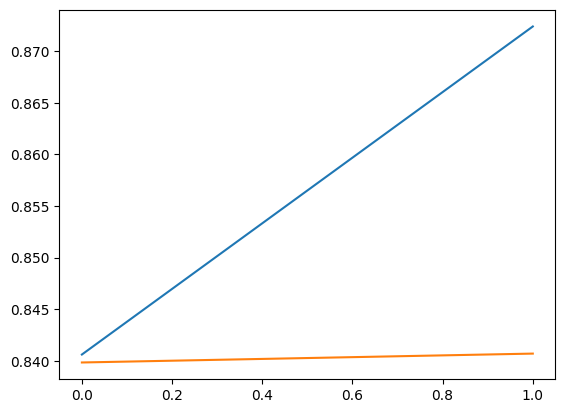

In [54]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])